# 03 · Support Vector Machine (LinearSVC)
Loads pre-built features → tunes `C` on the **validation set** → evaluates on the held-out **test set**.

**Prerequisite:** `01_features_ml.ipynb`

In [1]:
import os, pickle, warnings, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
warnings.filterwarnings('ignore')

SEED = 42
INPUT_DIR = '../outputs/featured/'
OUTPUT_DIR = '../outputs/svm/'

os.makedirs(OUTPUT_DIR, exist_ok=True)

def load(name):
    with open(os.path.join(INPUT_DIR, f'{name}.pkl'), 'rb') as f:
        return pickle.load(f)

X_train = load('X_ml_feat_train')
X_val   = load('X_ml_feat_val')
X_test  = load('X_ml_feat_test')
y_train = load('y_train_np')
y_val   = load('y_val_np')
y_test  = load('y_test_np')

print(f'Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}')


Train: 27052 | Val: 5797 | Test: 5797


## 1 · Hyperparameter Tuning on Validation Set

In [2]:
C_values = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
val_scores = {}

for C in C_values:
    clf = LinearSVC(C=C, max_iter=2000, random_state=SEED)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_val)
    f1 = f1_score(y_val, preds, average='weighted')
    val_scores[C] = f1
    print(f'  C={C:<5}  Val F1={f1:.4f}')

best_C = max(val_scores, key=val_scores.get)
print(f'\nBest C: {best_C}  (Val F1={val_scores[best_C]:.4f})')


  C=0.01   Val F1=0.9489
  C=0.1    Val F1=0.9820
  C=0.5    Val F1=0.9883
  C=1.0    Val F1=0.9898
  C=2.0    Val F1=0.9902
  C=5.0    Val F1=0.9905

Best C: 5.0  (Val F1=0.9905)


## 2 · Train Final Model

In [3]:
svm = LinearSVC(C=best_C, max_iter=2000, random_state=SEED)
svm.fit(X_train, y_train)
print('Model trained.')


Model trained.


## 3 · Evaluate on Test Set


=== SVM ===
  Accuracy  : 0.9898
  Precision : 0.9898
  Recall    : 0.9898
  F1        : 0.9898

              precision    recall  f1-score   support

        Fake       0.99      0.98      0.99      2619
        Real       0.99      0.99      0.99      3178

    accuracy                           0.99      5797
   macro avg       0.99      0.99      0.99      5797
weighted avg       0.99      0.99      0.99      5797



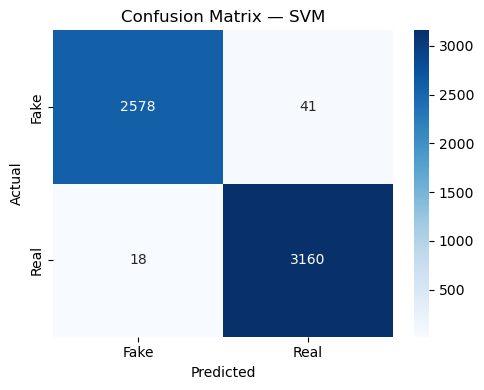

In [4]:
def evaluate(name, y_true, y_pred):
    metrics = dict(
        Accuracy  = accuracy_score(y_true, y_pred),
        Precision = precision_score(y_true, y_pred, average='weighted'),
        Recall    = recall_score(y_true, y_pred, average='weighted'),
        F1        = f1_score(y_true, y_pred, average='weighted'),
    )
    print(f'\n=== {name} ===')
    for k, v in metrics.items():
        print(f'  {k:10s}: {v:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=['Fake', 'Real']))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fake','Real'], yticklabels=['Fake','Real'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'cm_{name.replace(" ","_")}.png'), dpi=120)
    plt.show()
    return metrics

y_pred_svm = svm.predict(X_test)
metrics_svm = evaluate('SVM', y_test, y_pred_svm)


## 4 · Save Model & Predictions

In [5]:
joblib.dump(svm, os.path.join(OUTPUT_DIR, 'model_svm.pkl'))

with open(os.path.join(OUTPUT_DIR, 'pred_svm.pkl'), 'wb') as f:
    pickle.dump(y_pred_svm, f)

with open(os.path.join(OUTPUT_DIR, 'metrics_svm.json'), 'w') as f:
    json.dump({'best_C': best_C, 'val_scores': val_scores, 'test': metrics_svm}, f, indent=2)

print('Saved: model_svm.pkl, pred_svm.pkl, metrics_svm.json')


Saved: model_svm.pkl, pred_svm.pkl, metrics_svm.json
